In [4]:
%pip install transformers torch scikit-learn pandas numpy -q

In [5]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

token_data = {
    "username": "dikshaganchaudhuri16",
    "key": "KGAT_c4eb79f830df4453ce2526c9bda8c534"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(token_data, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle configured successfully!")

!pip install kaggle -q
!kaggle datasets download -d yelp-dataset/yelp-dataset
!unzip -q yelp-dataset.zip
!ls

Kaggle configured successfully!
Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 4.06G/4.07G [00:58<00:00, 143MB/s] 
100% 4.07G/4.07G [00:58<00:00, 74.5MB/s]
Dataset_User_Agreement.pdf	     yelp_academic_dataset_review.json
sample_data			     yelp_academic_dataset_tip.json
yelp_academic_dataset_business.json  yelp_academic_dataset_user.json
yelp_academic_dataset_checkin.json   yelp-dataset.zip


In [7]:
from io import StringIO
import pandas as pd
import numpy as np

chunks = []
with open('yelp_academic_dataset_review.json', 'r') as f:
    for i, line in enumerate(f):
        if i >= 50000:
            break
        chunks.append(pd.read_json(StringIO(line), typ='series'))

df = pd.DataFrame(chunks)[['text', 'stars']].rename(columns={'text': 'review', 'stars': 'rating'})

def map_rating(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['rating'] = df['rating'].apply(map_rating)

neg = df[df['rating'] == 0]
neu = df[df['rating'] == 1]
pos = df[df['rating'] == 2]

min_count = min(len(neg), len(neu), len(pos))

df = pd.concat([
    neg.sample(min_count, random_state=42),
    neu.sample(min_count, random_state=42),
    pos.sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['rating'].value_counts())
print(df.head())

(17031, 2)
rating
0    5677
2    5677
1    5677
Name: count, dtype: int64
                                              review  rating
0  The lady at the front desk was amazing, we got...       0
1  We enjoyed a drink up on the balcony before ou...       2
2  I think drinks are watered down at every night...       1
3  I've lived here for about 5 years but never ev...       1
4  A co-worker & I decided we'd earned a margarit...       0


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [14]:
class YelpDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len=128):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        review = str(self.reviews[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("Dataset class redefined successfully")

Dataset class redefined successfully


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['rating'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['rating'].values
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Create datasets
train_dataset = YelpDataset(X_train, y_train, tokenizer)
test_dataset  = YelpDataset(X_test,  y_test,  tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Training samples: 13624
Testing samples:  3407
Train batches: 426
Test batches:  107


In [16]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)
model = model.to(device)
print("Model loaded successfully")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Model parameters: 109,484,547


In [17]:
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {total_steps // 10}")

Total training steps: 1278
Warmup steps: 127


In [18]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids     = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels        = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 30)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc     = eval_epoch(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

print("\nTraining complete!")


Epoch 1/3
------------------------------
Train Loss: 0.7030 | Train Acc: 0.6787
Val Loss:   0.5249 | Val Acc:   0.7670

Epoch 2/3
------------------------------
Train Loss: 0.4514 | Train Acc: 0.8131
Val Loss:   0.5240 | Val Acc:   0.7790

Epoch 3/3
------------------------------
Train Loss: 0.3243 | Train Acc: 0.8796
Val Loss:   0.5841 | Val Acc:   0.7772

Training complete!


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81      1135
     Neutral       0.67      0.68      0.68      1136
    Positive       0.84      0.85      0.84      1136

    accuracy                           0.78      3407
   macro avg       0.78      0.78      0.78      3407
weighted avg       0.78      0.78      0.78      3407



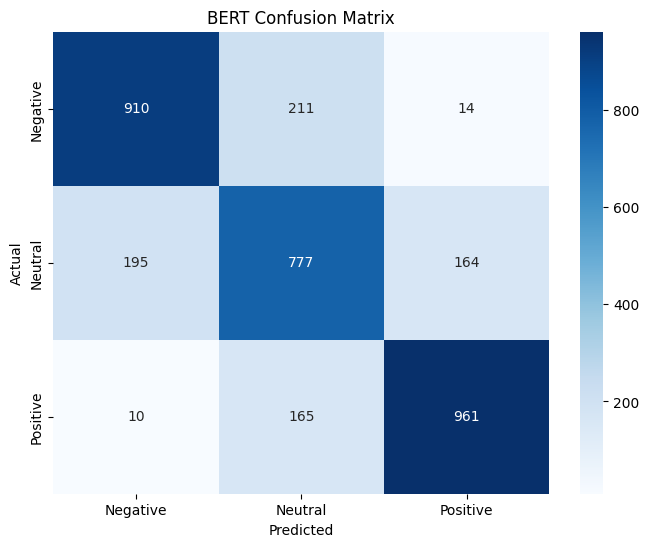

In [20]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('BERT Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('bert_confusion_matrix.png')
plt.show()

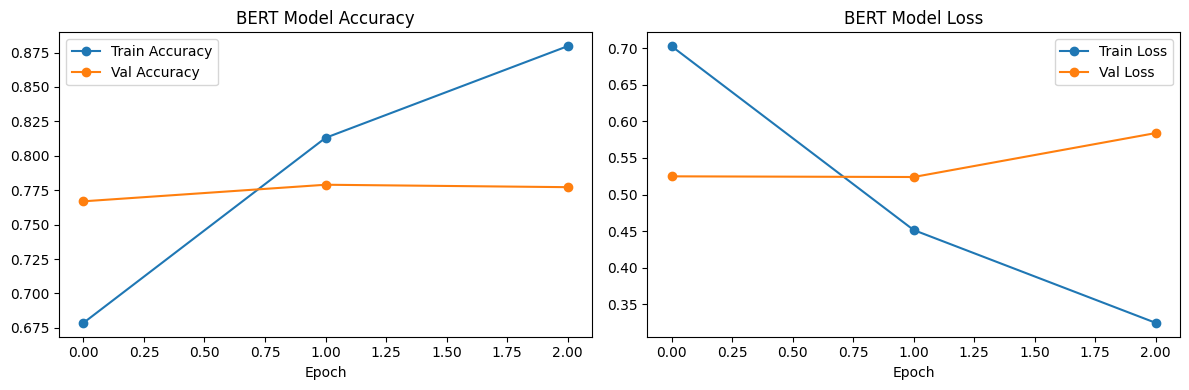

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', marker='o')
plt.plot(history['val_acc'], label='Val Accuracy', marker='o')
plt.title('BERT Model Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('BERT Model Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('bert_training_curves.png')
plt.show()

In [22]:
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

def predict_review(review_text):
    encoding = tokenizer(
        review_text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item() * 100

    return label_names[predicted_class], confidence

# Test on tricky and straightforward reviews
all_reviews = [
    # Tricky
    "Not bad at all, quite enjoyed it",
    "Could have been worse I suppose",
    "It works, I guess",
    "Surprisingly didn't break immediately",
    "My cat loves sitting on the box it came in",
    # Straightforward
    "This is the worst product I have ever bought!",
    "Really happy with my purchase, great quality!",
    "It is decent, nothing too great or too bad.",
    "Absolutely loved this place, food was incredible!",
    "Very disappointing, expected much better.",
]

print("\n--- BERT Review Predictions ---")
for review in all_reviews:
    sentiment, confidence = predict_review(review)
    print(f"Review:    '{review}'")
    print(f"Sentiment: {sentiment} ({confidence:.1f}% confidence)\n")


--- BERT Review Predictions ---
Review:    'Not bad at all, quite enjoyed it'
Sentiment: Neutral (92.8% confidence)

Review:    'Could have been worse I suppose'
Sentiment: Negative (51.9% confidence)

Review:    'It works, I guess'
Sentiment: Neutral (71.8% confidence)

Review:    'Surprisingly didn't break immediately'
Sentiment: Neutral (55.0% confidence)

Review:    'My cat loves sitting on the box it came in'
Sentiment: Positive (83.1% confidence)

Review:    'This is the worst product I have ever bought!'
Sentiment: Negative (99.2% confidence)

Review:    'Really happy with my purchase, great quality!'
Sentiment: Positive (98.7% confidence)

Review:    'It is decent, nothing too great or too bad.'
Sentiment: Neutral (92.9% confidence)

Review:    'Absolutely loved this place, food was incredible!'
Sentiment: Positive (98.8% confidence)

Review:    'Very disappointing, expected much better.'
Sentiment: Negative (95.1% confidence)

